# Data Preparation

## 🏠 `Houses` dataset

In [1]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = None

data = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset.csv")

data = data[['GrLivArea','BedroomAbvGr','KitchenAbvGr', 'OverallCond',
             'Pesos','Alley','Street','WallMat','SalePrice']]

data.shape

(1760, 9)

In [2]:
data.head(3)

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Alley,Street,WallMat,SalePrice
0,1710,3,1,5,4170000.0,NaN,Pave,Concrete,208500
1,1262,3,1,8,3630000.0,NaN,Pave,Wood,181500
2,1786,3,1,5,4470000.0,NaN,Pave,Wood,223500


# (1) 👥 Duplicates

### 💻 `drop_duplicates` (and `.duplicated`)

In [3]:
# Check number of rows before removing duplicates
len(data)

1760

In [4]:
# Check whether a row is a duplicated version of a previous row
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1755     True
1756     True
1757     True
1758     True
1759     True
Length: 1760, dtype: bool

In [5]:
# Compute the number of duplicated rows
data.duplicated().sum()

303

In [6]:
# Remove duplicates
data = data.drop_duplicates()
# Check new number of rows
len(data)

1457

# (2) 🔮 Missing Data 

### 💻 Detecting missing data

In [7]:
# Counting the number of NaN for each column
data.isnull().sum()

GrLivArea          0
BedroomAbvGr       0
KitchenAbvGr       0
OverallCond        0
Pesos             10
Alley           1367
Street             0
WallMat         1452
SalePrice          0
dtype: int64

In [8]:
# Counting the percentage of NaN for each column
pd.Series(data.isnull().sum()/len(data)).sort_values(ascending=False)

WallMat         0.996568
Alley           0.938229
Pesos           0.006863
GrLivArea       0.000000
BedroomAbvGr    0.000000
KitchenAbvGr    0.000000
OverallCond     0.000000
Street          0.000000
SalePrice       0.000000
dtype: float64

### `WallMat`

In [9]:
# 99% is way too high, let's drop this feature
data.drop(columns = ['WallMat'], inplace = True)

### `Alley`


In [10]:
#How many REAL missing values?
data["Alley"].value_counts()

Grvl    50
Pave    40
Name: Alley, dtype: int64

In [11]:
# data["Alley"].replace(np.nan, "ZeroAlley", inplace = True)
data["Alley"] = data["Alley"].replace(np.nan, "ZeroAlley")

In [12]:
data["Alley"].value_counts()

ZeroAlley    1367
Grvl           50
Pave           40
Name: Alley, dtype: int64

### `Pesos`

In [13]:
# Percentage of missing values in Pesos
data.corr()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,SalePrice
GrLivArea,1.000000,0.519944,0.099954,-0.078613,0.708600,0.707813
BedroomAbvGr,0.519944,1.000000,0.198580,0.012627,0.177301,0.168229
KitchenAbvGr,0.099954,0.198580,1.000000,-0.087120,-0.136017,-0.136225
OverallCond,-0.078613,0.012627,-0.087120,1.000000,-0.076181,-0.078067
Pesos,0.708600,0.177301,-0.136017,-0.076181,1.000000,1.000000
SalePrice,0.707813,0.168229,-0.136225,-0.078067,1.000000,1.000000


In [14]:
data.drop(columns = ["Pesos"], inplace = True)

### 🖥 Sklearn's `SimpleImputer`

📚[**sklearn.impute.SimpleImputer**](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [15]:
pesos = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset.csv")
pesos = pesos[['Pesos']]
pesos.shape

(1760, 1)

In [16]:
pesos.isnull().sum()

Pesos    13
dtype: int64

In [17]:
# Import it
from sklearn.impute import SimpleImputer

In [18]:
# Instantiate a SimpleImputer object
# with your strategy of choice
simple_imputer = SimpleImputer(strategy = "mean")

In [19]:
# Call the "fit" method on the object
simple_imputer.fit(pesos)

SimpleImputer()

In [20]:
# What did the imputer learn ?
simple_imputer.statistics_

array([3631104.40755581])

In [21]:
np.mean(pesos)

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


Pesos    3.631104e+06
dtype: float64

In [22]:
# Call the "transform" method on the object
pesos_without_nans = simple_imputer.transform(pesos)
pesos_without_nans.shape

(1760, 1)

In [23]:
pd.DataFrame(pesos_without_nans).isnull().sum()

0    0
dtype: int64

# (3) 🐳 Outliers

## Detecting Outliers - Boxplot

We can use ***boxplots*** visualize outliers within a dataset.

In [24]:
len(data)

1457

<Axes: >

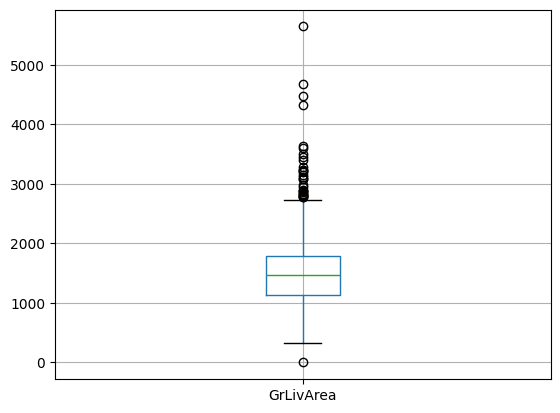

In [25]:
# Is there any house with an abnormal living area ?
data[["GrLivArea"]].boxplot()

In [26]:
# Boolean mask
boolean_mask = data["GrLivArea"]>0
boolean_mask

0       True
1       True
2       True
3       True
4       True
        ... 
1455    True
1456    True
1457    True
1458    True
1459    True
Name: GrLivArea, Length: 1457, dtype: bool

In [27]:
# Dataset based on the boolean mask
data = data[boolean_mask]

In [28]:
# Visualize boxplot again
data[["GrLivArea"]].boxplot()

<Axes: >

In [29]:
data[["SalePrice"]].boxplot()

<Axes: >

In [30]:
luxury_price = 300_000
luxury_mask = (data["SalePrice"] > luxury_price)
data[luxury_mask].shape

(115, 7)

# (4) 🔢 Feature Scaling

👇 Look at our dataset, which of these features are 🔢 numerical features? 

In [31]:
data.head(3)

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Alley,Street,SalePrice
0,1710,3,1,5,ZeroAlley,Pave,208500
1,1262,3,1,8,ZeroAlley,Pave,181500
2,1786,3,1,5,ZeroAlley,Pave,223500


<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/lecture_preparedatsaset_houses_features.png">

_Note: this conversation rate can evolve, let's use this one in the lecture_.

In [32]:
# Columns' types
data.dtypes

GrLivArea        int64
BedroomAbvGr     int64
KitchenAbvGr     int64
OverallCond      int64
Alley           object
Street          object
SalePrice        int64
dtype: object

In [33]:
# Store the numerical features here
#data.select_dtypes(exclude = "object")
data_num = data.select_dtypes(include = "int64")

👉 Let's scale the `GrLivArea` as an example.

What is the **distribution** of the `GrLivArea` feature ❓

In [34]:
# Plot the distribution here
import seaborn as sns
sns.histplot(data['GrLivArea'], bins=200,kde = True);

Does `GrLivArea` have outliers ❓

In [35]:
# Inspect the potential outliers here
sns.boxplot(data=data, x='GrLivArea')

<Axes: xlabel='GrLivArea', ylabel='Count'>

Which scaler should we apply to the `GrLiveArea` feature ❓

In [36]:
# Import the scaler you chose
from sklearn.preprocessing import RobustScaler

In [37]:
# Instanciate it
robust_scaler = RobustScaler()

In [38]:
# Fit it on the feature.s you want to scale
robust_scaler.fit(data[["GrLivArea"]])

RobustScaler()

In [39]:
# What did the scaler "learn"?
learned_median = robust_scaler.center_
learned_median

array([1465.])

In [40]:
learned_iqr = robust_scaler.scale_
learned_iqr

array([648.25])

In [41]:
# Transform your features
# area_robust_scaled = robust_scaler.transform(data[["GrLivArea"]])

In [42]:
data[["GrLivArea"]] = robust_scaler.transform(data[["GrLivArea"]])

# (5) ⚖️ Dataset balancing

📚 [SMOTE documentation](https://imbalanced-learn.org/stable/over_sampling.html#over-sampling)

ℹ️ Notice that you have to `pip install -U imbalanced-learn`

👉 Imbalanced-learn (imported as `imblearn`) is an open source, MIT-licensed library relying on `scikit-learn` (imported as `sklearn`) and provides tools when dealing with classification with imbalanced classes.



🚨 Why balancing is not necessarily a magical tool? 

- [Yotame Elor (Amazon) & Hadar Averbuch Elor (Cornell) - To SMOTE or not to SMOTE ?](https://arxiv.org/pdf/2201.08528.pdf)

- [Stop using SMOTE to treat Class Imbalance](https://towardsdatascience.com/stop-using-smote-to-treat-class-imbalance-take-this-intuitive-approach-instead-9cb822b8dc45)

Ali Soleymani shows that `class weights` are much simpler (coding wise and computationally wise) to implement 



# (6) 🔠 Encoding

## (6.1) Feature Encoding with _OrdinalEncoder_


👇 Look at the following feature _"classes"_. 

In [43]:
example = pd.DataFrame({"classes":["bad", "average", "average", "good", "good", "bad", "good"]})
example

,classes
0,bad
1,average
2,average
3,good
4,good
5,bad
6,good


In [44]:
example.value_counts()

classes
good       3
average    2
bad        2
dtype: int64

🤔 How would a Machine Learning algorithm understand these classes? 

👩🏿‍💻 Let's convert this column into numbers!

In [45]:
# Import the Ordinal Encoder
from sklearn.preprocessing import OrdinalEncoder

In [46]:
# Instantiate the Ordinal Encoder
ordinal_encoder = OrdinalEncoder(categories = [["bad","average","good"]])

In [47]:
# Fit it
ordinal_encoder.fit(example)

OrdinalEncoder(categories=[['bad', 'average', 'good']])

In [48]:
# What categories has the ordinal encoder learn?
ordinal_encoder.categories_

[array(['bad', 'average', 'good'], dtype=object)]

In [49]:
example

,classes
0,bad
1,average
2,average
3,good
4,good
5,bad
6,good


In [50]:
# Transforming categories into ordered numbers
example_ordinal_encoded = ordinal_encoder.transform(example)
example_ordinal_encoded

array([[0.],
       [1.],
       [1.],
       [2.],
       [2.],
       [0.],
       [2.]])

## (6.2) Feature Encoding with _OneHotEncoder_


### 💻 One-hot-Encoding `Alley`

In [51]:
# Check unique values for streets (3)
data["Alley"].value_counts()

ZeroAlley    1366
Grvl           50
Pave           40
Name: Alley, dtype: int64

In [52]:
# Import the OHE
from sklearn.preprocessing import OneHotEncoder

In [53]:
# Instantiate the OneHotEncoder
ohe = OneHotEncoder(sparse_output = False)

In [54]:
# Fit the OHE
ohe.fit(data[["Alley"]])

OneHotEncoder(sparse_output=False)

In [55]:
# Display the detected categories learned by the model
ohe.categories_

[array(['Grvl', 'Pave', 'ZeroAlley'], dtype=object)]

In [56]:
# Encoding
data[ohe.get_feature_names_out()] = ohe.transform(data[["Alley"]])

In [57]:
data.drop(columns = ["Alley"], inplace = True)
data.head(2)

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Street,SalePrice,Alley_Grvl,Alley_Pave,Alley_ZeroAlley
0,0.377941,3,1,5,Pave,208500,0.0,0.0,1.0
1,-0.313151,3,1,8,Pave,181500,0.0,0.0,1.0


### 💻 One-hot Encoding `Street` 

In [58]:
data["Street"].value_counts()

Pave    1450
Grvl       6
Name: Street, dtype: int64

In [59]:
# Copy paste the code above
from sklearn.preprocessing import OneHotEncoder
ohe_binary = OneHotEncoder(drop = "if_binary", sparse_output = False)
ohe_binary.fit(data[["Street"]])
data[ohe_binary.get_feature_names_out()] = ohe_binary.transform(data[["Street"]])
data.drop(columns = ["Street"], inplace = True)
data.head(2)

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,SalePrice,Alley_Grvl,Alley_Pave,Alley_ZeroAlley,Street_Pave
0,0.377941,3,1,5,208500,0.0,0.0,1.0,1.0
1,-0.313151,3,1,8,181500,0.0,0.0,1.0,1.0


## (6.3) _LabelEncoder_

🐧 Let's say that we want to predict the species of penguins.

In [60]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [61]:
target = penguins["species"]
target.value_counts()

Adelie       152
Gentoo       124
Chinstrap     68
Name: species, dtype: int64

📚 [**sklearn.preprocessing.LabelEncoder**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)

In [62]:
# Import the Label Encoder
from sklearn.preprocessing import LabelEncoder

In [63]:
# Instantiate the LabelEncoder
label_encoder = LabelEncoder()

In [64]:
# Fit it to the target
label_encoder.fit(target)

LabelEncoder()

In [65]:
# Find the encoded classes "learned" by the LabelEncoder
label_encoder.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [66]:
# Transform the targets
encoded_target = label_encoder.transform(target)
encoded_target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [67]:
# Showing the target and the encoded target side by side
pd.DataFrame({"target":target,"encoded_target":encoded_target}).sample(10)

,target,encoded_target
343,Gentoo,2
153,Chinstrap,1
255,Gentoo,2
209,Chinstrap,1
310,Gentoo,2
251,Gentoo,2
180,Chinstrap,1
217,Chinstrap,1
77,Adelie,0
41,Adelie,0


💡 You can revert back to the original target:

In [68]:
# Inverse Transform
original_target = label_encoder.inverse_transform(encoded_target)

### 🖥 Discretizing Sale Price

In [69]:
data['SalePriceBinary'] = pd.cut(x = data['SalePrice'],
                                 bins=[data['SalePrice'].min()-1,
                                       data['SalePrice'].mean(),
                                       data['SalePrice'].max()+1],
                                 labels=['cheap', 'expensive'])

data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,SalePrice,Alley_Grvl,Alley_Pave,Alley_ZeroAlley,Street_Pave,SalePriceBinary
0,0.377941,3,1,5,208500,0.0,0.0,1.0,1.0,expensive
1,-0.313151,3,1,8,181500,0.0,0.0,1.0,1.0,expensive
2,0.495179,3,1,5,223500,0.0,0.0,1.0,1.0,expensive
3,0.388739,3,1,5,140000,0.0,0.0,1.0,1.0,cheap
4,1.130737,4,1,5,250000,0.0,0.0,1.0,1.0,expensive


# (8) 🟨 Feature creation

📚[**sklearn.preprocessing**](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing)

# (9) 🤖 Feature selection, Modeling and Feature Permutation

### 💻 Feature permutation in Sklearn


👉 Instead of predicting the `SalePrice` (Regression Task), let's predict the `SalePriceBinary` (Binary Classification Task)

In [70]:
X = data.drop(columns = ["SalePrice", "SalePriceBinary"])
y = data["SalePriceBinary"]


* Score without Permutation and without scaling:

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Model to be cross-validated
log_model = LogisticRegression(max_iter = 1000)

# Cross Validation
np.mean(cross_val_score(log_model, X, y , cv=5))

0.8406628065715764

* Score without Permutation but with Scaling so that all features are treated with the same importance by the algorithm:

In [72]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
robust_scaler.fit(X)
X_scaled = pd.DataFrame(robust_scaler.transform(X), columns = robust_scaler.get_feature_names_out())

In [73]:
from sklearn.model_selection import cross_val_score

# Model to be cross-validated
log_model = LogisticRegression(max_iter = 1000)

# Cross Validation
np.mean(cross_val_score(log_model, X_scaled, y , cv=5))

0.8406628065715764

* Permutation:

In [74]:
from sklearn.inspection import permutation_importance

# Fit model
log_model = LogisticRegression(max_iter=1000).fit(X_scaled, y)

# Performs Permutation
permutation_score = permutation_importance(log_model, X_scaled, y, n_repeats=10)

# Unstack results showing the decrease in performance after shuffling features
importance_df = pd.DataFrame(np.vstack((X.columns,
                                        permutation_score.importances_mean)).T)
importance_df.columns=['feature','score decrease']

# Show the important features
importance_df.sort_values(by="score decrease", ascending = False)

,feature,score decrease
0,GrLivArea,0.307898
1,BedroomAbvGr,0.032212
2,KitchenAbvGr,0.019643
6,Alley_ZeroAlley,0.007418
4,Alley_Grvl,0.004876
3,OverallCond,0.00103
7,Street_Pave,-0.000206
5,Alley_Pave,-0.000481


* Model with the strongest features:

In [75]:
# Selecting the strongest features
strongest_feature = X_scaled[["GrLivArea"]]

# Re-instantiating a Logistic Regression
log_reg = LogisticRegression()

# Average accuracy of the cross-validated model
np.mean(cross_val_score(log_reg, strongest_feature, y, cv=10))

0.7890599905526688